Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Final Project**  

In [1]:
%pip install -q ucimlrepo

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Problem Definition and Dataset Selection

This project focuses on **predicting concrete compressive strength**, a real-world problem in construction and civil engineering. Compressive strength measures how much pressure concrete can withstand before failing. It depends on the ingredients used and the time allowed for curing. The project will use supervised machine learning with **Regression**, since the target is a numerical strength value measured in megapascals (MPa). **Linear Regression** and **Random Forest Regression** will be implemented in Python using scikit-learn.

The selected dataset is **Concrete Compressive Strength** from the **UCI Machine Learning Repository**. It contains 1,030 observations and eight numerical input features: cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, and age. The target variable is concrete compressive strength. The dataset can be loaded directly into Python without manually uploading files.

UCI reports no missing values, making the dataset a manageable starting point. Before training, its quality will be checked for missing values, duplicate records, invalid values, and unusual observations. All input features are numerical, so categorical encoding is unnecessary. Numerical features will be scaled for Linear Regression, with preprocessing fitted only on the training set to prevent data leakage. These checks will help ensure the data is suitable for modelling.

Predicting concrete strength is important because physical testing takes time and resources. A reliable model could support early strength estimates, help engineers compare concrete mixtures, and reduce unnecessary material trials. The project therefore addresses a practical challenge involving construction quality, cost, and material efficiency. Model predictions would support engineering decisions rather than replace required physical testing.

## Dataset source: **https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength**

## 2. Data Preprocessing and Exploration

**- Load the dataset**

In [3]:
dataset = fetch_ucirepo(id=165)

df = dataset.data.features.copy()
df.columns = [
    "Cement", "Slag", "Fly_Ash", "Water",
    "Superplasticizer", "Coarse_Aggregate",
    "Fine_Aggregate", "Age"
]
df["Strength"] = dataset.data.targets.iloc[:, 0]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1030, 9)


,Cement,Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


**- Explore the data**

In [4]:
df.info()
display(df.describe().round(2))
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cement            1030 non-null   float64
 1   Slag              1030 non-null   float64
 2   Fly_Ash           1030 non-null   float64
 3   Water             1030 non-null   float64
 4   Superplasticizer  1030 non-null   float64
 5   Coarse_Aggregate  1030 non-null   float64
 6   Fine_Aggregate    1030 non-null   float64
 7   Age               1030 non-null   int64  
 8   Strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


,Cement,Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60



Missing values:
Cement              0
Slag                0
Fly_Ash             0
Water               0
Superplasticizer    0
Coarse_Aggregate    0
Fine_Aggregate      0
Age                 0
Strength            0
dtype: int64

Duplicate rows: 25


**- Clean the data**

In [5]:
df = df.drop_duplicates().copy()
df = df.dropna(subset=["Strength"])

# Reject impossible negative quantities and non-positive ages/strengths
ingredient_columns = df.columns.drop(["Age", "Strength"])
invalid = ((df[ingredient_columns] < 0).any(axis=1) | (df["Age"] <= 0) | (df["Strength"] <= 0))
print("Invalid rows removed:", invalid.sum())

df = df.loc[~invalid].reset_index(drop=True)
print("Cleaned shape:", df.shape)

Invalid rows removed: 0
Cleaned shape: (1005, 9)


**- Visualize distributions**

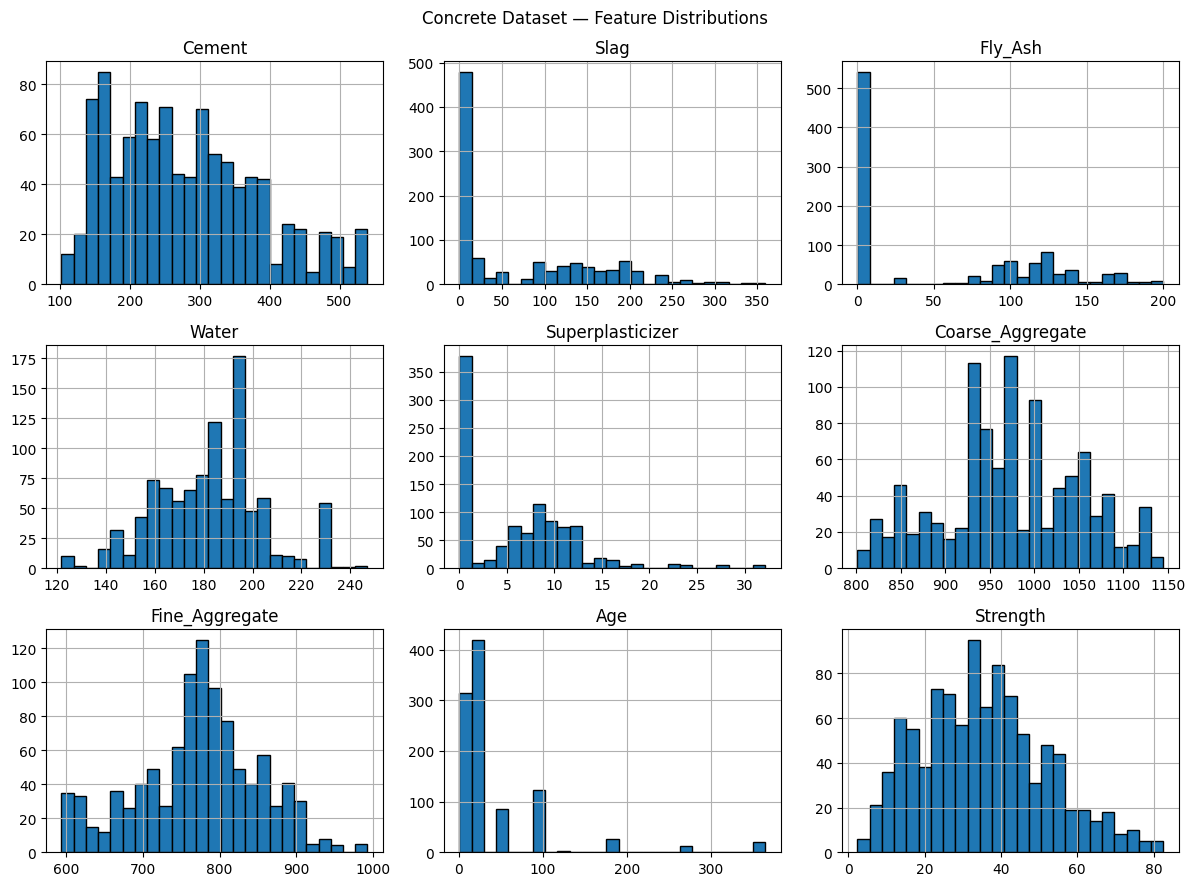

In [6]:
df.hist(bins=25, figsize=(12, 9), edgecolor="black")
plt.suptitle("Concrete Dataset — Feature Distributions")
plt.tight_layout()
plt.show()

**- Inspect potential outliers**

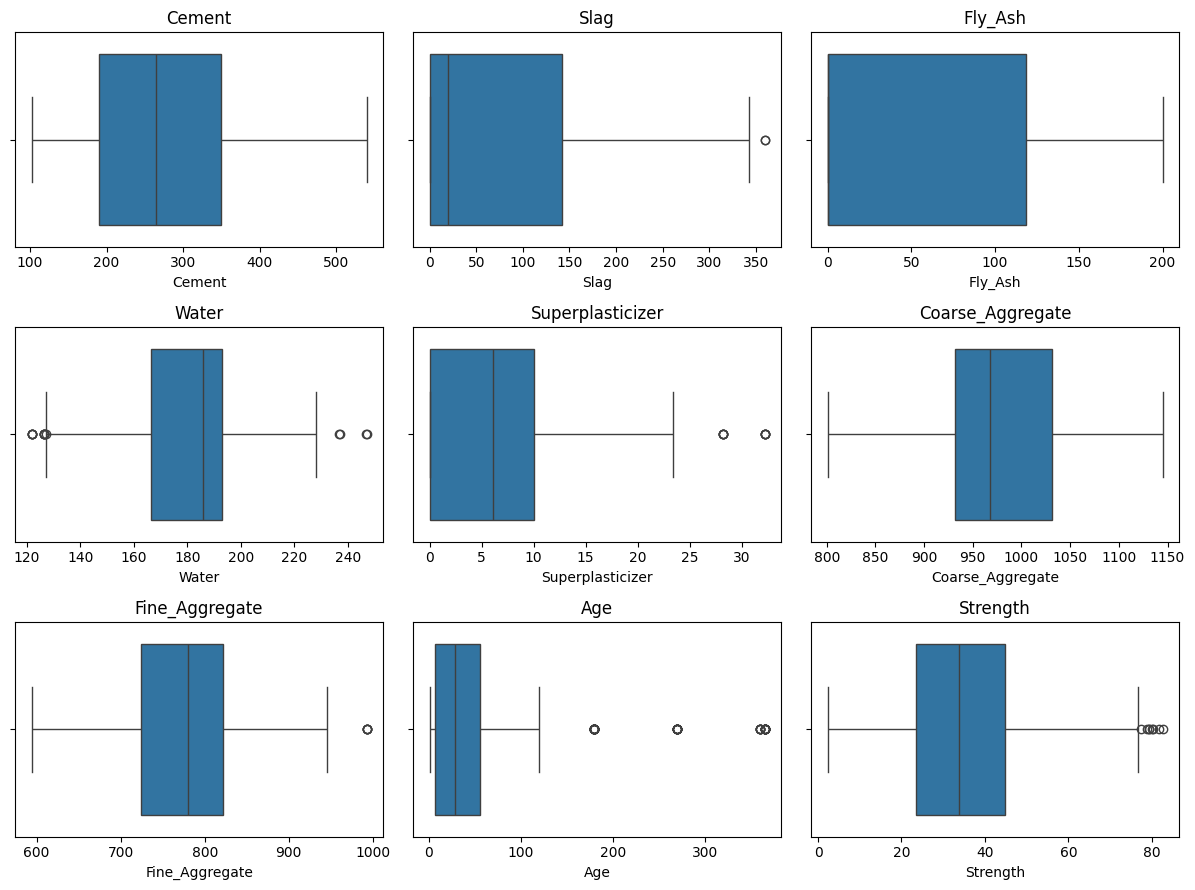

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for column, ax in zip(df.columns, axes.flat):
    sns.boxplot(x=df[column], ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

**- Visualize relationships with strength**

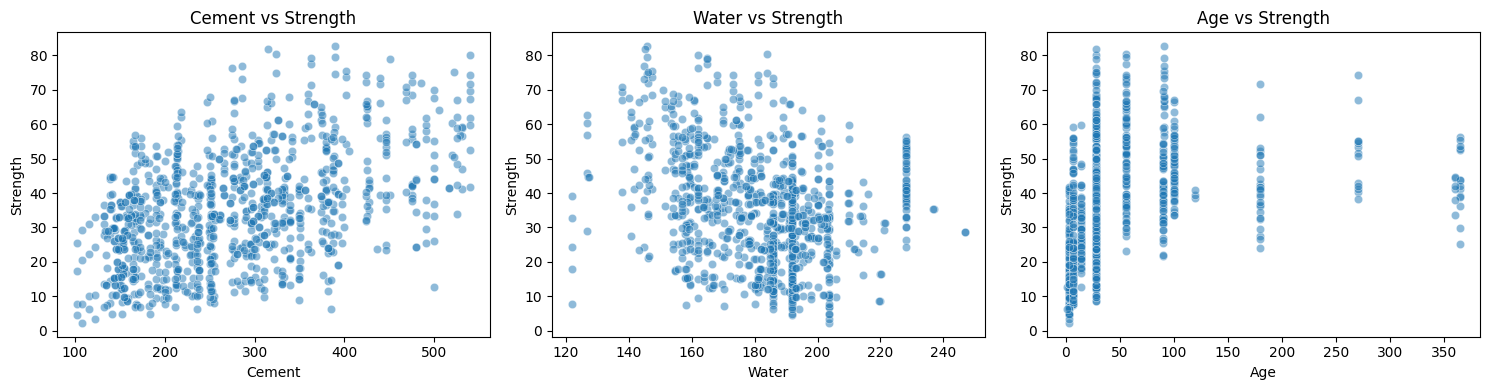

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for column, ax in zip(["Cement", "Water", "Age"], axes):
    sns.scatterplot(data=df, x=column, y="Strength", alpha=0.5, ax=ax)
    ax.set_title(f"{column} vs Strength")
plt.tight_layout()
plt.show()

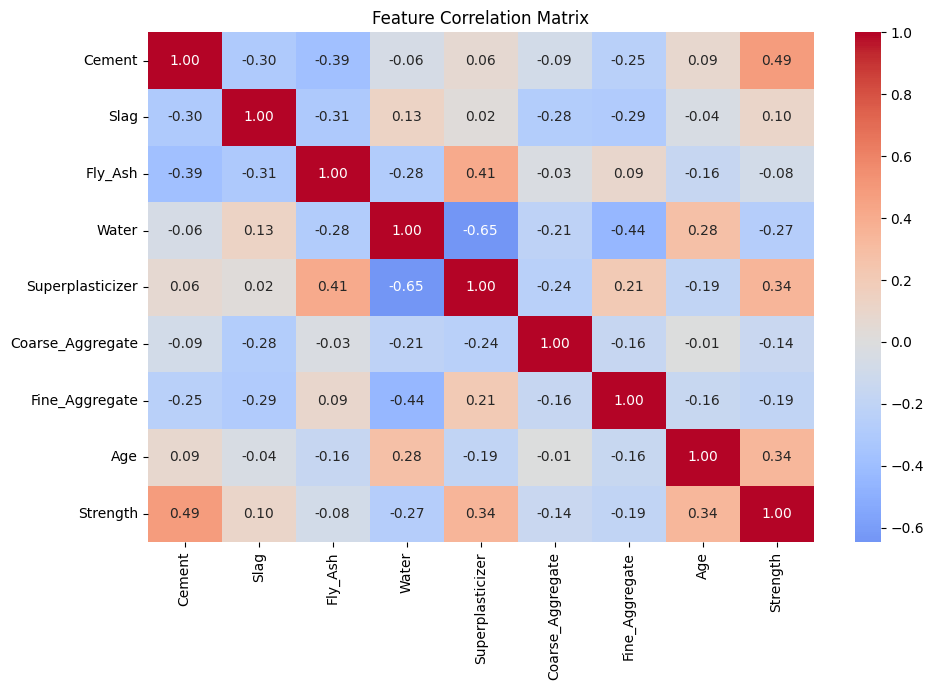

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**- Split into training and testing sets**

In [10]:
X = df.drop(columns="Strength")
y = df["Strength"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 804
Testing samples: 201


**- Handle any remaining missing input values**

In [11]:
imputer = SimpleImputer(strategy="median")
X_train_clean = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_clean = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

**- Scale the numerical features**

In [12]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_clean), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_clean), columns=X.columns, index=X_test.index)
X_train_scaled.head()

,Cement,Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age
78,2.436728,-0.837655,-0.875865,-1.872881,3.720106,-1.560059,1.487304,-0.679041
29,1.894731,-0.837655,-0.875865,2.132243,-1.023026,-0.525673,-2.218565,-0.614850
280,-0.010441,-0.837655,0.638711,-0.999374,0.961689,0.016765,1.263493,-0.679041
507,1.519280,-0.837655,-0.875865,1.667611,-1.023026,-1.737419,-0.664251,-0.277844
652,-1.072293,2.070419,-0.875865,0.993895,-1.023026,0.038774,-0.999350,-0.614850


## 3. Model Selection and Development

**- Parameter grid**

In [14]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15],
    "min_samples_leaf": [1, 2]
}

**- Train and tune using cross-validation**

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv, n_jobs=-1, verbose=1
)
grid_search.fit(X_train_clean, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 15], 'min_samples_leaf': [1, 2],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

**- Retrieve the best trained model**

In [16]:
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print(f"Mean CV RMSE: {-grid_search.best_score_:.2f} MPa")

best_index = grid_search.best_index_
cv_std = grid_search.cv_results_["std_test_score"][best_index]
print(f"CV RMSE standard deviation: {cv_std:.2f} MPa")

Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 200}
Mean CV RMSE: 5.34 MPa
CV RMSE standard deviation: 0.49 MPa


## 4. Model Evaluation and Optimization

**- Predict concrete strength on the test set**

In [18]:
y_pred = best_model.predict(X_test_clean)

**- Performance metrics**

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} MPa")
print(f"RMSE: {rmse:.2f} MPa")
print(f"R²:   {r2:.4f}")

MAE:  3.53 MPa
RMSE: 5.18 MPa
R²:   0.9099


**- Actual and predicted values comparison**

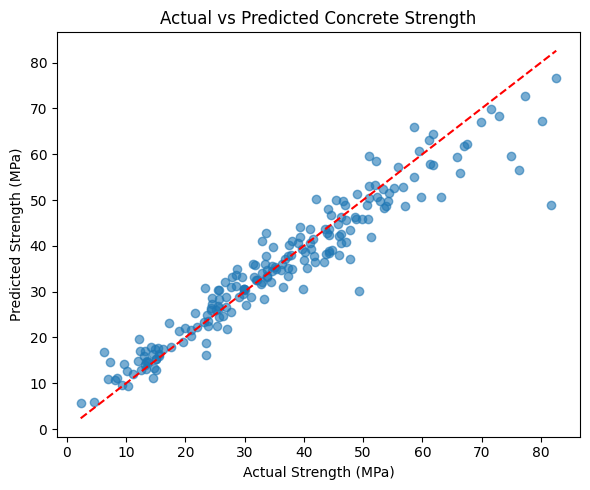

In [20]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot([low, high], [low, high], "r--")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs Predicted Concrete Strength")
plt.tight_layout()
plt.show()

## 5. Model Deployment and Presentation

**- A user-friendly interface**

In [24]:
#@title Predict Concrete Strength

Cement = 300.0 #@param {type:"number"}
Slag = 0.0 #@param {type:"number"}
Fly_Ash = 0.0 #@param {type:"number"}
Water = 180.0 #@param {type:"number"}
Superplasticizer = 5.0 #@param {type:"number"}
Coarse_Aggregate = 1000.0 #@param {type:"number"}
Fine_Aggregate = 800.0 #@param {type:"number"}
Age = 28 #@param {type:"integer"}

values = [
    Cement, Slag, Fly_Ash, Water, Superplasticizer,
    Coarse_Aggregate, Fine_Aggregate, Age
]

if any(value < 0 for value in values[:-1]) or Age <= 0:
    print("Ingredient quantities must be non-negative, and age must be positive.")
else:
    new_data = pd.DataFrame([values], columns=X_train_clean.columns)
    prediction = best_model.predict(new_data)[0]

    print(f"Predicted concrete strength: {prediction:.2f} MPa")

Predicted concrete strength: 29.55 MPa


**- Conclusion and Key Findings**

The heatmap shows that cement has the strongest positive correlation with concrete strength (0.49). Age and superplasticizer also have positive correlations (0.34 each), while water has a negative correlation (−0.27). These relationships reveal useful patterns, but do not prove causation.

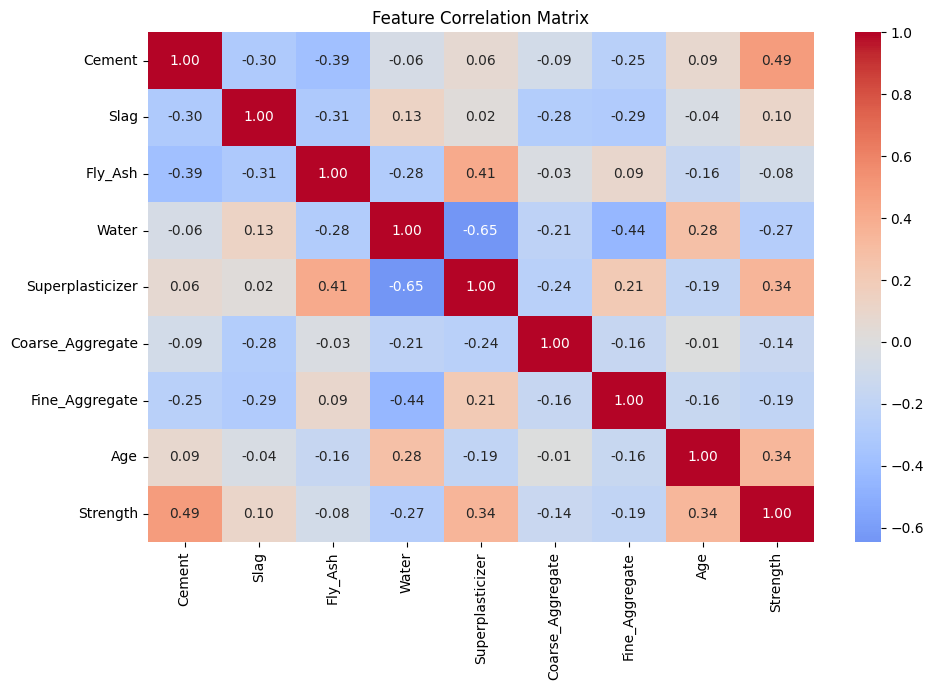

In [32]:
#@title Feature Correlation Matrix
# Feature Correlation Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Most predictions lie close to the red dashed line, indicating good agreement with actual strength values. The model achieved an MAE of 3.53 MPa, RMSE of 5.18 MPa, and R² of 0.9099, explaining approximately 91% of test-set strength variation. Some high-strength samples were underestimated, showing room for improvement.

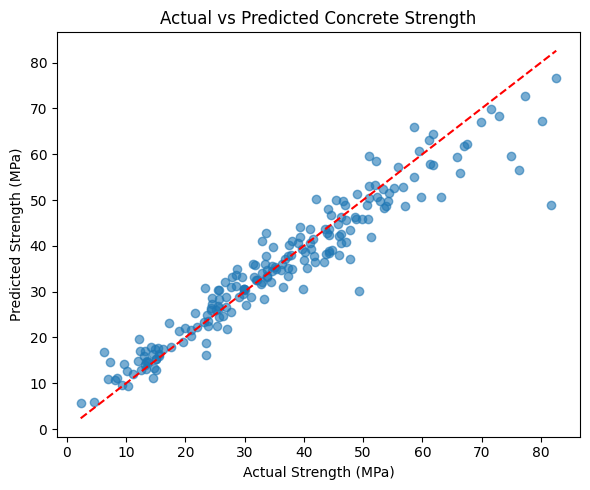

In [33]:
#@title Actual vs Predicted Concrete Strength
# Actual vs Predicted Concrete Strength
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot([low, high], [low, high], "r--")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs Predicted Concrete Strength")
plt.tight_layout()
plt.show()

In [34]:
!find "/content/drive/MyDrive" -iname "Final_project.ipynb"

find: ‘/content/drive/MyDrive’: No such file or directory


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
!ls -la /content/colab-git-assignment2-ST

ls: cannot access '/content/colab-git-assignment2-ST': No such file or directory


In [37]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 101 (delta 35), reused 40 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 3.91 MiB | 10.34 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [38]:
!ls -la /content/colab-git-assignment2-ST

total 3800
drwxr-xr-x 10 root root    4096 Sep 20 20:23  .
drwxr-xr-x  1 root root    4096 Sep 20 20:23  ..
drwxr-xr-x  2 root root    4096 Sep 20 20:23  Assignment_11
drwxr-xr-x  2 root root    4096 Sep 20 20:23  Assignment_12
drwxr-xr-x  2 root root    4096 Sep 20 20:23  Assignment_13
drwxr-xr-x  2 root root    4096 Sep 20 20:23  Assignment_14
-rw-r--r--  1 root root  490404 Sep 20 20:23  Assignment_15.ipynb
-rw-r--r--  1 root root    5415 Sep 20 20:23  assignment2.ipynb
drwxr-xr-x  2 root root    4096 Sep 20 20:23  Assignment_8
drwxr-xr-x  2 root root    4096 Sep 20 20:23  Assignment_9
drwxr-xr-x  8 root root    4096 Sep 20 20:23  .git
drwxr-xr-x  2 root root    4096 Sep 20 20:23  Lesson_10_assignment
-rw-r--r--  1 root root   12704 Sep 20 20:23  Lesson_3_assignment.ipynb
-rw-r--r--  1 root root   80271 Sep 20 20:23 'Lesson 4 assignment.ipynb'
-rw-r--r--  1 root root  549515 Sep 20 20:23  Lesson_5_Assignment.ipynb
-rw-r--r--  1 root root 2321005 Sep 20 20:23  Lesson_6_ml_basic_assig